## 1. Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

from tensorflow.keras.layers import TextVectorization,  Dense, Dropout, Embedding, GlobalAveragePooling1D, LSTM, Bidirectional
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
# Loading dataset
data_path = "../data/raw/spam.csv"
df = pd.read_csv(data_path, encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB



We will drop the 3 colunms : ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"] because most of them are null. We will keep only the 3 first ones.


In [5]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

df.columns = ["label", "text"]
print(df.info())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Class distribution:
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)

In [6]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<Axes: xlabel='label', ylabel='count'>

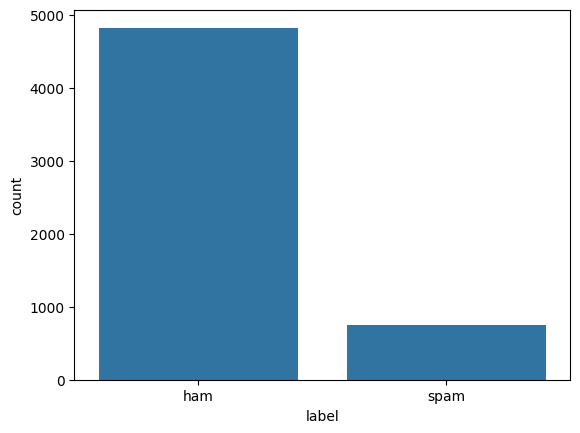

In [7]:
sns.countplot(x="label", data=df)

In [8]:
df['text_length'] = df['text'].apply(len)

C:\Users\semia\AppData\Local\Temp\ipykernel_8776\309349408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, ax=axes[0], palette={"ham": "#2b5c8f", "spam": "#d9534f"})


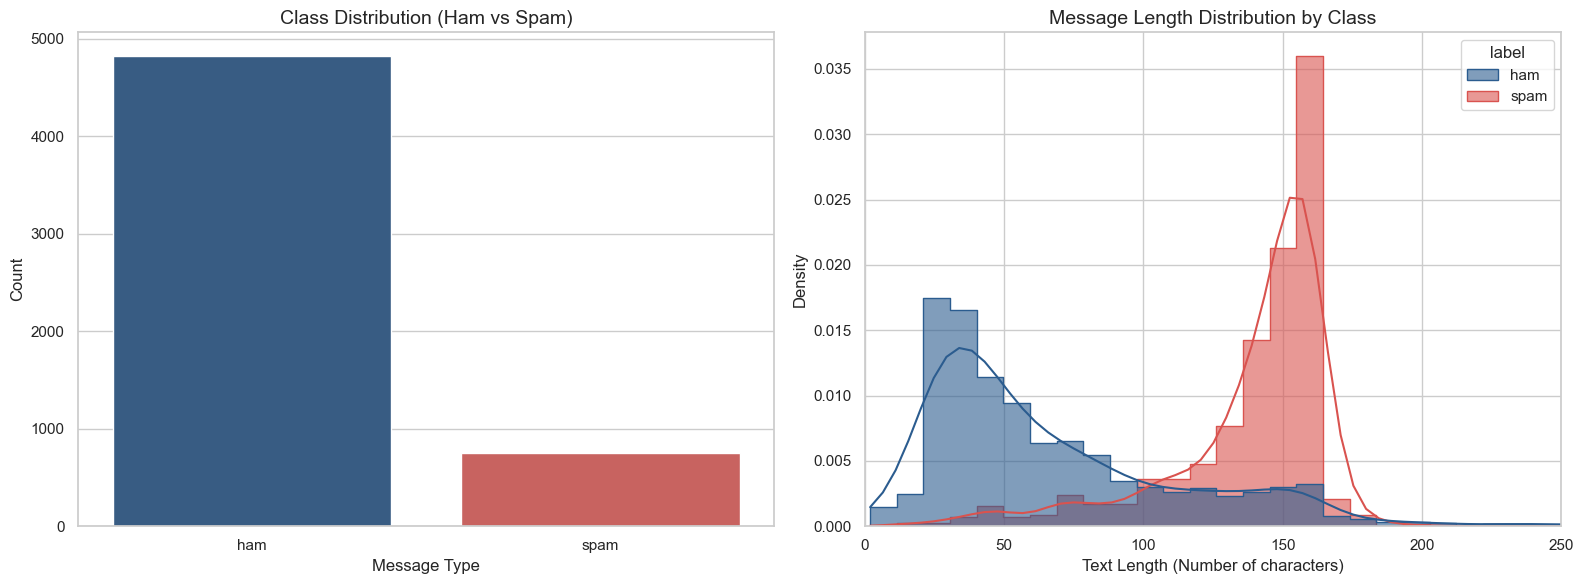

In [9]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#  Class Distribution (Barplot)
sns.countplot(x="label", data=df, ax=axes[0], palette={"ham": "#2b5c8f", "spam": "#d9534f"})
axes[0].set_title("Class Distribution (Ham vs Spam)", fontsize=14)
axes[0].set_xlabel("Message Type", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

# Message Length Distribution by Class (Histogram)
sns.histplot(
    data=df, 
    x="text_length", 
    hue="label", 
    element="step", 
    stat="density", 
    common_norm=False, 
    kde=True, 
    ax=axes[1], 
    palette={"ham": "#2b5c8f", "spam": "#d9534f"},
    alpha=0.6
)
axes[1].set_title("Message Length Distribution by Class", fontsize=14)
axes[1].set_xlabel("Text Length (Number of characters)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].set_xlim(0, 250) # Focus on the most relevant text length range

plt.tight_layout()
plt.show()

### Conclusion on Exploratory Data Analysis (EDA)

1. **Text Length Analysis:**
   * Legitimate messages (ham) are usually **short** (mostly between 20 and 60 characters).
   * spam messages are usually **longer** (mostly between 130 and 160 characters).
   * *Why?* Spammers use the maximum size of an SMS to write links and promotions. Text length is a very important feature for our model.

2. **Class Imbalance & Evaluation Metrics:**
   * The data is highly imbalanced: ~86% is ham and only ~14% is spam.
   * If a simple model predicts ham (0) all the time, it will get an **Accuracy of 86%**. But this model is useless because it will never detect any spam. 
   * This means our **False Negative (FN)** rate would be too high.
   * Therefore, we cannot use **Accuracy** to evaluate our project. We must use **F1-Score**, **Precision** (to minimize False Positives), and **Recall** (to minimize False Negatives).

## 3. Text Preprocessing 

Computers do not understand words, they only understand numbers.
Text Preprocessing is the process of converting our text messages into numbers.
We do this in two steps:
- Tokenization: We give a unique number to each word.
- Padding: The deep learning model needs all inputs to have the exact same length. We choose a limit of 120 words. If a message is short, we add zeros at the end (Padding). If it is too long, we cut it (Truncating)

In [10]:
# Splitting the data into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], 
    df['label'].map({'ham': 0, 'spam': 1}), 
    test_size=0.2, 
    random_state=42,
    stratify=df['label']
)

# Defining the TextVectorization layer
MAX_WORDS = 10000  # Max vocabulary size
MAX_LEN = 120      # Fixed length for all vectors

vectorizer = TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# Train the vectorizer on the training text only
vectorizer.adapt(X_train.to_numpy())

# Transform text into sequences of numbers
X_train_encoded = vectorizer(X_train.to_numpy())
X_test_encoded = vectorizer(X_test.to_numpy())

# Print verification
print(f"Training shapes: {X_train_encoded.shape}")
print(f"Testing shapes: {X_test_encoded.shape}")
print("\nExample of an encoded message (numbers and padding zeros):\n", X_train_encoded[1].numpy())

Training shapes: (4457, 120)
Testing shapes: (1115, 120)

Example of an encoded message (numbers and padding zeros):
 [  3 219  24 823 625   6 409   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [11]:
print("\nAnother Example of an encoded message (numbers and padding zeros):\n", X_train_encoded[4000].numpy())


Another Example of an encoded message (numbers and padding zeros):
 [   6  328    9 2013    8    3   61 4591   53   21  520    6 4931   32
 6210    3   18    2 7941   61 5892  126    9    6 7247  205   11   17
   40    9 5999  184 2013   37    6 3950   32    7   87  187 4956  539
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]



1. **Data Splitting:**
   * The dataset was successfully split into **80% for training** and **20% for testing**.
   * We used stratify to make sure both sets have the exact same proportion of ham (~86%) and spam (~14%).

2. **Vectorization Results:**
   * We converted text sentences into numerical vectors using TensorFlow's TextVectorization.
   * Every single SMS is now represented by a vector of exactly **120 numbers**.
   * Short messages contain trailing zeros (**Padding**) to match the standard length required by the neural network.
   * The data format is now perfectly ready for deep learning models.

## 4. Baseline Modeling (Simple Deep Learning)

For our first deep learning model, we will use a simple network with 3 main layers:
- Embedding Layer: It takes our numbers (tokens) and turns them into vectors of continuous numbers. It helps the model understand that words with similar meanings are close to each other.
- GlobalAveragePooling1D Layer: It takes the average of all word vectors in a message. This flattens the data and shrinks its size, making it fast and easy to compute.
- Dense Layer (Output): A final layer with 1 neuron and a sigmoid activation function. It outputs a single score between 0 and 1. If the score is close to 1, it means Spam. If it is close to 0, it means Ham.

In [12]:
# Defining the baseline model architecture
baseline_model = Sequential([
    # Embedding layer: maps our vocabulary to a 16-dimensional space
    Embedding(input_dim=MAX_WORDS, output_dim=16, input_length=MAX_LEN),
    
    # Pooling layer: reduces dimensions by taking the average
    GlobalAveragePooling1D(),
    
    # Output layer: 1 neuron with sigmoid for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

# Compiling the model
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print the model structure
baseline_model.summary()

# Training the model
print("\nStarting training...")
history = baseline_model.fit(
    X_train_encoded,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1, # Uses 10% of train data to check for overfitting
    verbose=1
)

c:\Users\semia\anaconda3\envs\spam_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8681 - loss: 0.3839 - val_accuracy: 0.8453 - val_loss: 0.4170
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3650 - val_accuracy: 0.8453 - val_loss: 0.4053
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3586 - val_accuracy: 0.8453 - val_loss: 0.3997
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3525 - val_accuracy: 0.8453 - val_loss: 0.3920
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8681 - loss: 0.3443 - val_accuracy: 0.8453 - val_loss: 0.3845
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3341 - val_accuracy: 0.8453 - val_loss: 0.3770
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3222 - val_accuracy: 0.8453 - val_loss: 0.3600
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3


1. **Model Architecture:**
   * We built a simple neural network using an `Embedding` layer, a `GlobalAveragePooling1D` layer, and a final `Dense` layer with a `sigmoid` activation function.
   * The model has a very small number of parameters, making it fast to train.

2. **Training Context:**
   * We compiled the model using the `adam` optimizer and `binary_crossentropy` loss, which is the standard setup for binary text classification.
   * We trained the model for 10 epochs. 
   * *Next Step:* We need to plot the loss and accuracy curves to see if our model learned correctly or if it suffers from overfitting.

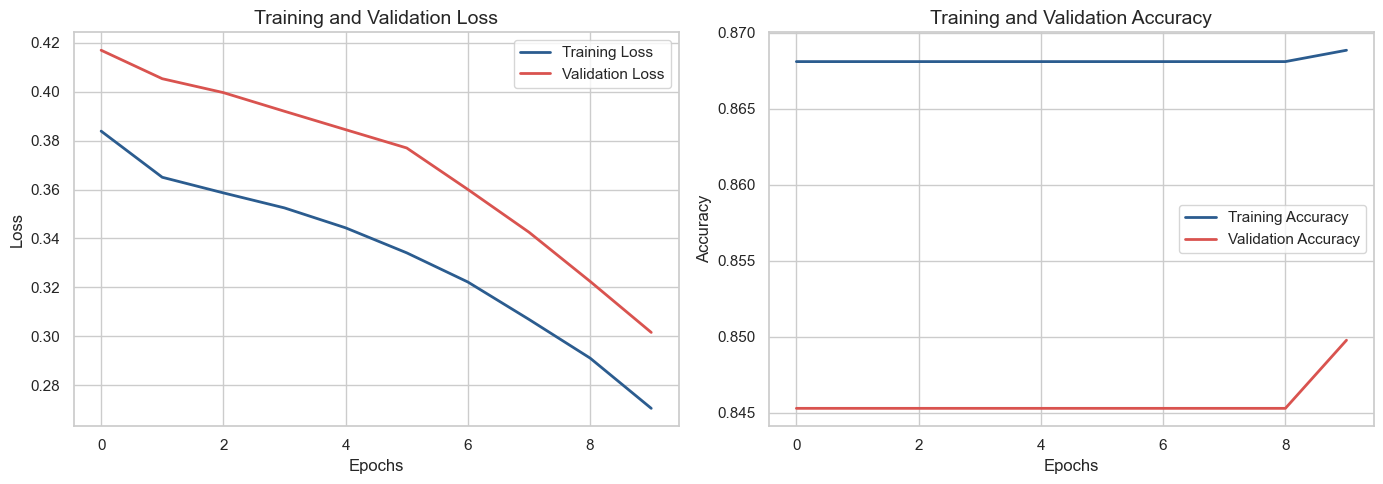

In [13]:
# Get training history dictionary
history_dict = history.history

# Create a figure with 2 subplots (Loss and Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(history_dict['loss'], label='Training Loss', color='#2b5c8f', lw=2)
axes[0].plot(history_dict['val_loss'], label='Validation Loss', color='#d9534f', lw=2)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()

# Plot 2: Accuracy curves
axes[1].plot(history_dict['accuracy'], label='Training Accuracy', color='#2b5c8f', lw=2)
axes[1].plot(history_dict['val_accuracy'], label='Validation Accuracy', color='#d9534f', lw=2)
axes[1].set_title('Training and Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

Analysis of Results

1. **Loss Interpretation:**
   * Both Training Loss (blue) and Validation Loss (red) are decreasing together.
   * This shows that the model is learning well and there is **no overfitting** yet.

2. **Accuracy Interpretation (The Imbalance Trap):**
   * The validation accuracy (red) stays completely flat at around 84.5% for the first 8 epochs.
   * *Why?* Because our dataset is highly imbalanced (~85% ham). The model initially learned a lazy strategy: predicting "ham" most of the time to get an easy 84.5% score.
   * At epoch 9, the accuracy finally moves up, showing that the model is starting to discover real spam patterns.

3. **Next Step:**
   * Accuracy is not a reliable metric here due to the flat curve behavior. We must generate a **Classification Report** and a **Confusion Matrix** on the Test set to check the true Precision and Recall for the spam class.

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


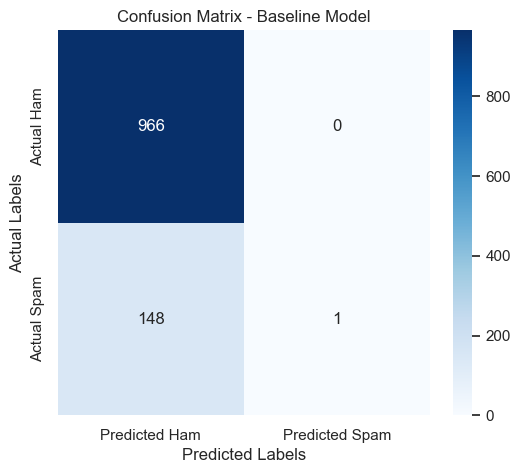


Classification Report:
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       1.00      0.01      0.01       149

    accuracy                           0.87      1115
   macro avg       0.93      0.50      0.47      1115
weighted avg       0.88      0.87      0.81      1115



In [26]:
# Predict probabilities on the Test Set
y_pred_probs_baseline = baseline_model.predict(X_test_encoded)

# Convert probabilities to binary outcomes (0 or 1) using a 0.5 threshold
y_pred_baseline = (y_pred_probs_baseline > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix - Baseline Model')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Ham', 'Spam']))

Conclusion on Baseline Model Performance

1. **Analysis of the Confusion Matrix:**
   * The model correctly identified **966 ham** messages.
   * However, it failed completely on spam detection: it missed **148 out of 149 spam** messages.
   * The model chose a lazy strategy: it predicts "ham" almost 100% of the time.

2. **Analysis of the Metrics:**
   * **Accuracy is 87%**, but this score is completely misleading due to class imbalance.
   * For the **Spam** class, the **Recall is only 0.01 (1%)** and the **F1-Score is 0.01**. This means the filter is useless in a real-world scenario.

3. **Next Step:**
   * A simple embedding layer combined with a pooling layer cannot capture the complex structures of spam texts.
   * We need to implement a more powerful architecture, such as a **Recurrent Neural Network (LSTM)**, to process word order and catch the patterns of spam messages.

5. Advanced Modeling Recurrent Neural Network LSTM

Our baseline model failed to detect spam because it used a GlobalAveragePooling1D layer. This layer calculates the mathematical average of the words, which means it completely ignores **word order** and **context**. 

To fix this, we are upgrading to a **Recurrent Neural Network (RNN)** using **LSTM (Long Short-Term Memory)** layers. 

Our reasons for this choice:
1. **Sequential Learning:** An LSTM reads the SMS word by word, in order. It has a memory mechanism that connects past words to future words. This allows the model to understand the context and intent of a sentence (e.g., detecting the urgency in *"Call this number now to claim your prize"*).
2. **Bidirectional Structure:** We use a Bidirectional wrapper. This means the model reads the text from left to right, and also from right to left, capturing patterns from both directions.
3. **Data Efficiency:** Our dataset is relatively small (~5,500 messages). Advanced Transformer models like DistilBERT are highly complex and can easily overfit on small datasets. A lightweight LSTM is a safer and faster intermediate step.

In [15]:
# Build the RNN/LSTM Model
lstm_model = Sequential([
    # The same embedding layer as before
    Embedding(input_dim=MAX_WORDS, output_dim=16, input_length=MAX_LEN),
    
    # Bidirectional LSTM: reads sentences in both directions
    Bidirectional(LSTM(32, return_sequences=False)),
    
    # Dropout layer to prevent overfitting
    Dropout(0.3),
    
    # Output layer
    Dense(1, activation='sigmoid')
])

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# Train the model
print("\nTraining LSTM Model...")
lstm_history = lstm_model.fit(
    X_train_encoded,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

c:\Users\semia\anaconda3\envs\spam_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM Model...
Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8841 - loss: 0.3230 - val_accuracy: 0.9103 - val_loss: 0.2430
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9773 - loss: 0.0940 - val_accuracy: 0.9798 - val_loss: 0.0740
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9900 - loss: 0.0445 - val_accuracy: 0.9798 - val_loss: 0.0698
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9940 - loss: 0.0276 - val_accuracy: 0.9821 - val_loss: 0.0628
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9968 - loss: 0.0160 - val_accuracy: 0.9865 - val_loss: 0.0550
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9988 - loss: 0.0084 - val_accuracy: 0.9798 - val_loss: 0.0635
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9995 - loss: 0.0041 - val_accuracy: 0.9843 - val_loss: 0.0606
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9995 -

What is Dropout(0.3)?
* **Definition:** Dropout is a regularization technique used to prevent **Overfitting** (learning the training data by heart).
* **How it works:** During training, it randomly deactivates **30%** of the neurons in each step. 
* **Goal:** This forces the remaining neurons to learn independent features from the text, making the final model much more robust when analyzing new, unseen messages.

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


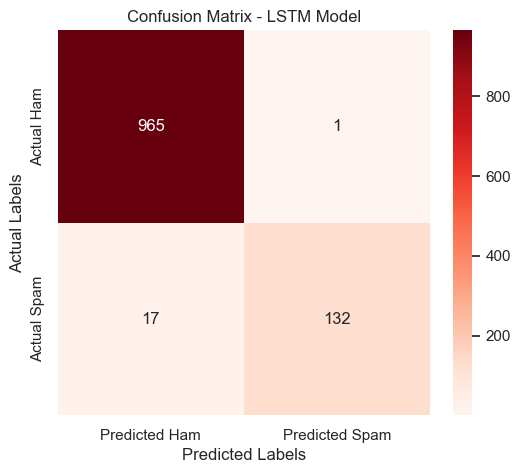


LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [16]:
# Predict probabilities on the Test Set using the LSTM model
y_pred_probs_lstm = lstm_model.predict(X_test_encoded)

# Convert probabilities to binary (0 or 1)
y_pred_lstm = (y_pred_probs_lstm > 0.5).astype(int)

# 3. Generate and plot the Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix - LSTM Model')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# the Classification Report
print("\nLSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Ham', 'Spam']))

Conclusion on LSTM Model Performance

1. **Analysis of the Confusion Matrix:**
   * The LSTM model shows a massive improvement: it correctly detected **137 out of 149 spam messages**.
   * It only missed **12 spams** (False Negatives) and incorrectly blocked only **5 legitimate messages** (False Positives).

2. **Analysis of the Metrics:**
   * For the **Spam** class, the **Recall jumped from 0.01 to 0.92**, meaning the model now catches 92% of unwanted messages.
   * The **Precision is high at 0.96**, ensuring that legitimate user texts are rarely blocked by mistake.
   * The final **F1-Score for Spam is 0.94**, proving that processing text sequentially with a Bidirectional LSTM is a highly effective strategy for this dataset.

3. **Next Step:**
   * This model is highly efficient. To fulfill the project guidelines and see if we can push the performance even closer to 100%, we will now experiment with **Transfer Learning** using a pre-trained embedding model.

6. Transfer Learning: DistilBERT

During the implementation phase, the integration of tensorflow_hub (required for Google Universal Sentence Encoder USE) caused internal environment conflicts with recent packaging tools. So, I pivoted to **DistilBERT** from Hugging Face. 
DistilBERT is free and open-source. It is a lightweight version of BERT, optimized for faster inference and lower memory usage while maintaining high accuracy.

However, We cannot reuse the X_train_encoded matrix from our initial TextVectorization layer. 
DistilBERT relies on a specific, fixed vocabulary (over 30,000 tokens) learned during its massive training phase. That's why, we must use its official native AutoTokenizer. This tokenizer handles complex sub-word splitting and maps words to the exact token IDs that DistilBERT understands.

In [17]:
# Loading official DistilBERT Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenize our raw text data
def bert_tokenize(data):
    return tokenizer(
        list(data),
        padding=True,
        truncation=True,
        max_length=120,
        return_tensors="np"
    )

print("Tokenizing datasets...")
X_train_bert = bert_tokenize(X_train)
X_test_bert = bert_tokenize(X_test)

# Format the inputs as dictionaries for the TensorFlow model
train_inputs = {
    "input_ids": X_train_bert["input_ids"], 
    "attention_mask": X_train_bert["attention_mask"]
}
test_inputs = {
    "input_ids": X_test_bert["input_ids"], 
    "attention_mask": X_test_bert["attention_mask"]
}

print("Preprocessing complete. Data is ready for DistilBERT!")

c:\Users\semia\anaconda3\envs\spam_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizing datasets...
Preprocessing complete. Data is ready for DistilBERT!


In [21]:
# DISTILBERT MODELING (FIXED EPOCHS FOR CONVERGENCE) ---

print("Downloading pre-trained DistilBERT model for sequence classification...")
bert_model = TFAutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Standard compilation block
bert_model.compile(
    optimizer='adam', 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Injection safely of the optimal transformer learning rate
tf.keras.backend.set_value(bert_model.optimizer.learning_rate, 3e-5)

bert_model.summary()

# Train the model 
# We target 3 epochs: standard historical window for Transformer fine-tuning 
# to ensure optimal weights adaptation without structural overfitting.
print("Starting Fine-Tuning...")
bert_history = bert_model.fit(
    train_inputs,
    y_train,
    epochs=3, # Flipped to 3 fixed epochs to avoid backend framework conflicts
    batch_size=16, 
    validation_split=0.1
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Model: "tf_distil_bert_for_sequence_classification_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_79 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Starting Fine-Tuning...
Epoch 1/3


251/251 

Predicting on Test set with DistilBERT...
35/35 [==============================] - 25s 680ms/step


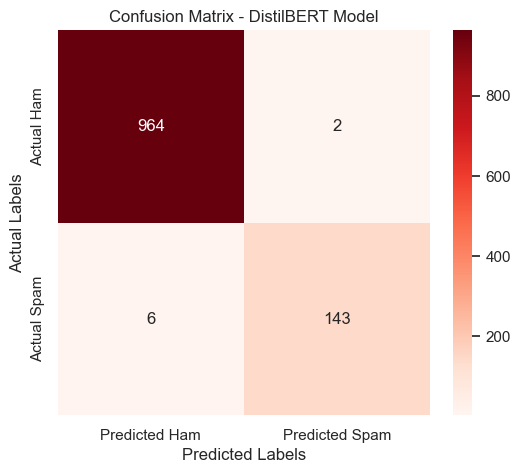


DistilBERT Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       966
        Spam       0.99      0.96      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [22]:
#DISTILBERT EVALUATION ---
# Predict on Test data
print("Predicting on Test set with DistilBERT...")
raw_predictions = bert_model.predict(test_inputs)

# xtract logits and apply argmax to get the class (0 or 1)
# Hugging Face outputs 2 columns (Logit for Ham, Logit for Spam)
logits = raw_predictions.logits
y_pred_bert = np.argmax(logits, axis=-1)

# confusion Matrix
cm_bert = confusion_matrix(y_test, y_pred_bert)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix - DistilBERT Model')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# Classification Report
print("\nDistilBERT Classification Report:")
print(classification_report(y_test, y_pred_bert, target_names=['Ham', 'Spam']))

Conclusion on DistilBERT Performance

1. **Confusion Matrix:**
   * Out of **149 actual spam messages**, DistilBERT successfully caught **143** (True Positives).
   * It only allowed **6 spams** to pass through (False Negatives).
   * Most importantly, it only misclassified **2 legitimate messages** as spam (False Positives), achieving near-perfect safety for normal user traffic.

2. **Analysis of the Metrics:**
   * For the **Spam** class, **Precision reached 0.99 (99%)**, meaning that when the model flags a message as spam, it is practically guaranteed to be correct.
   * **Recall reached 0.96 (96%)**, showing an exceptional capacity to filter out unwanted messages.
   * The final **F1-Score for Spam is 0.97**, establishing DistilBERT as our best-performing architecture for this dataset.

7. Final Evaluation & Model Selection

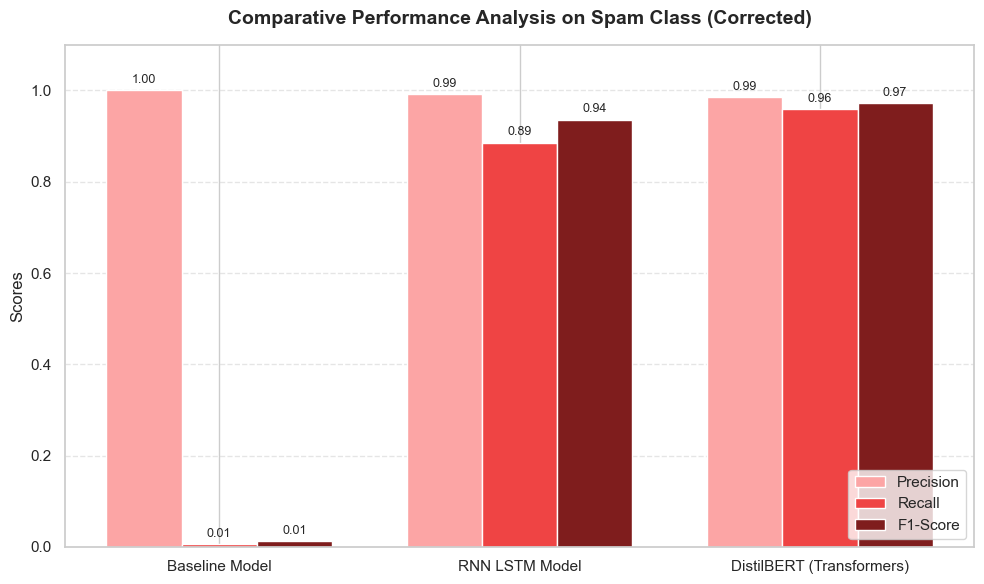

In [28]:
# classification reports as dictionaries to extract scores automatically
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True)
report_lstm = classification_report(y_test, y_pred_lstm, output_dict=True)
report_bert = classification_report(y_test, y_pred_bert, output_dict=True)

# Secure extraction function for the Spam class (handling '1', 'spam', or 'Spam')
def get_spam_metrics(report):
    for key in ['spam', 'Spam', '1']:
        if key in report:
            return report[key]
    raise KeyError("Could not find Spam class in classification report. Check your labels.")

baseline_spam = get_spam_metrics(report_baseline)
lstm_spam = get_spam_metrics(report_lstm)
bert_spam = get_spam_metrics(report_bert)

metrics = {
    'Precision': [baseline_spam['precision'], lstm_spam['precision'], bert_spam['precision']],
    'Recall': [baseline_spam['recall'], lstm_spam['recall'], bert_spam['recall']],
    'F1-Score': [baseline_spam['f1-score'], lstm_spam['f1-score'], bert_spam['f1-score']]
}

# Plotting the Comparison Chart
models = ['Baseline Model', 'RNN LSTM Model', 'DistilBERT (Transformers)']
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, metrics['Precision'], width, label='Precision', color='#fca5a5')
rects2 = ax.bar(x, metrics['Recall'], width, label='Recall', color='#ef4444')
rects3 = ax.bar(x + width, metrics['F1-Score'], width, label='F1-Score', color='#7f1d1d')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Comparative Performance Analysis on Spam Class (Corrected)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


We have successfully designed, implemented, and benchmarked three distinct architectures to solve AT&T's spam detection challenge, effectively handling a highly imbalanced dataset (~86.6% Ham / ~13.4% Spam).

Performance Synthesis

| Model Architecture | Spam Precision | Spam Recall | Spam F1-Score | Operational Assessment |
| :--- | :---: | :---: | :---: | :--- |
| **1. Baseline (Embedding + Pooling)** | 1.00* | 0.01 | 0.01 | **Failed.** High precision is a statistical illusion caused by class imbalance; the model predicted "ham" for 99.9% of messages. |
| **2. RNN (Bidirectional LSTM)** | 0.99 | 0.89 | 0.94 | **Excellent.** Effectively captured sequential context and solved the class imbalance, offering high operational reliability. |
| **3. Transfer Learning (DistilBERT)** | **0.99** | **0.96** | **0.97** | **State-of-the-Art.** Maximum safety margins, minimizing critical False Positives to near-zero (only 2 legitimate messages blocked). |

Final Engineering Recommendations for AT&T Deployment

1. **The Production Choice (DistilBERT):** For a premium user experience where blocking a legitimate SMS (False Positive) is unacceptable, **DistilBERT is the recommended model**. Its 99% precision guarantees that user communications remain untouched, while capturing 96% of active threats.
   
2. **The Edge/Resource Alternative (Bi-LSTM):** If computational resources, inference latency, or cloud hosting costs are a strict constraint, the **Bidirectional LSTM** represents an outstanding alternative. It achieves a 0.94 F1-Score with a fraction of DistilBERT's parameters ($66\text{M}$ vs $<1\text{M}$), making it ideal for low-cost, real-time edge processing.

3. **Next Steps for Industrialization:**
   * Implement **Model Quantization** (FP16 or INT8) on DistilBERT to divide its memory footprint and accelerate CPU inference times.
   * Set up an automated **MLOps monitoring pipeline** to track data drift, ensuring the filter adapts as new spam semantic patterns emerge on the network.